# Phase 2.5 — Normalisation: before & after

The first network analysis (notebook 02) ran on raw scispaCy output and
revealed three quality issues:

1. **Fragment artifacts.** "tyrosine" was the top entity by a huge
   margin (1,329 occurrences across CHEMICAL+GENE) — but as a
   stand-alone entity it's almost never what the abstracts are
   actually talking about. scispaCy was segmenting "tyrosine kinase
   inhibitor" and emitting the head noun separately. This produced
   a single artificial hub that absorbed 70% of all betweenness
   centrality.
2. **Acronym/expansion duplicates.** "NSCLC" and "non-small cell
   lung cancer" appeared as separate nodes despite being the same
   disease, with 213 edges connecting them to each other. Same for
   EGFR / "epidermal growth factor receptor" (116 edges), HCC /
   "hepatocellular carcinoma" (91 edges), CML / "chronic myeloid
   leukemia", and several others.
3. **Generic descriptors mis-classified as entities.** "toxicity",
   "death", "antitumor", "anticancer", "cellular", "malignancies"
   all appeared in the top 25 entities by frequency.

This notebook re-runs the analysis with `src/normalize.py` applied,
and shows the before/after numbers explicitly. The goal is to
demonstrate that even minimal hand-curated normalisation materially
sharpens the network — and to be honest about what it doesn't fix
(no UMLS linking, no synonym tables for rare entities).


## 1. Setup

In [3]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from src.network import (
    load_entities, entity_doc_frequency, filter_entities,
    cooccurrence_edges, build_graph, centrality_table, communities,
)
from src.normalize import apply_normalisation, normalisation_summary

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)


## 2. Load the raw entities and apply normalisation

In [4]:
ents_raw = load_entities()
ents_norm = apply_normalisation(ents_raw)

summary = normalisation_summary(ents_raw, ents_norm)
print("Normalisation summary:")
for k, v in summary.items():
    print(f"  {k}: {v:,}")

print()
print(f"Drop rate: {summary['occurrences_dropped'] / summary['occurrences_before']:.1%}")
print(f"Collapse rate: {summary['distinct_collapsed'] / summary['distinct_before']:.1%}")


Normalisation summary:
  occurrences_before: 49,594
  occurrences_after: 45,908
  occurrences_dropped: 3,686
  distinct_before: 10,386
  distinct_after: 10,286
  distinct_collapsed: 100

Drop rate: 7.4%
Collapse rate: 1.0%


## 3. Top entities — before vs after

The clearest visual evidence that normalisation is doing something
useful: the top-25 list should drop "tyrosine", "toxicity", "tki",
"tkis", and merge the acronym/expansion pairs.

In [5]:
def top_entities(df, n=20):
    return (entity_doc_frequency(df).head(n)
            [["norm", "type", "doc_freq"]]
            .reset_index(drop=True))


before_top = top_entities(ents_raw)
after_top = top_entities(ents_norm)

print("BEFORE (top 20):")
print(before_top.to_string(index=False))
print()
print("AFTER (top 20):")
print(after_top.to_string(index=False))


BEFORE (top 20):
                            norm     type  doc_freq
                        tyrosine CHEMICAL       889
                        tyrosine     GENE       440
                             tki CHEMICAL       335
                           nsclc  DISEASE       294
      non-small cell lung cancer  DISEASE       257
                            egfr     GENE       247
                            tkis CHEMICAL       171
                        toxicity  DISEASE       165
epidermal growth factor receptor     GENE       134
                        cellular     CELL       114
                           death  DISEASE       112
        hepatocellular carcinoma  DISEASE       105
                             hcc  DISEASE        98
            renal cell carcinoma  DISEASE        94
                   breast cancer  DISEASE        88
                     lung cancer  DISEASE        87
                       antitumor  DISEASE        85
                      anticancer  DISEASE      

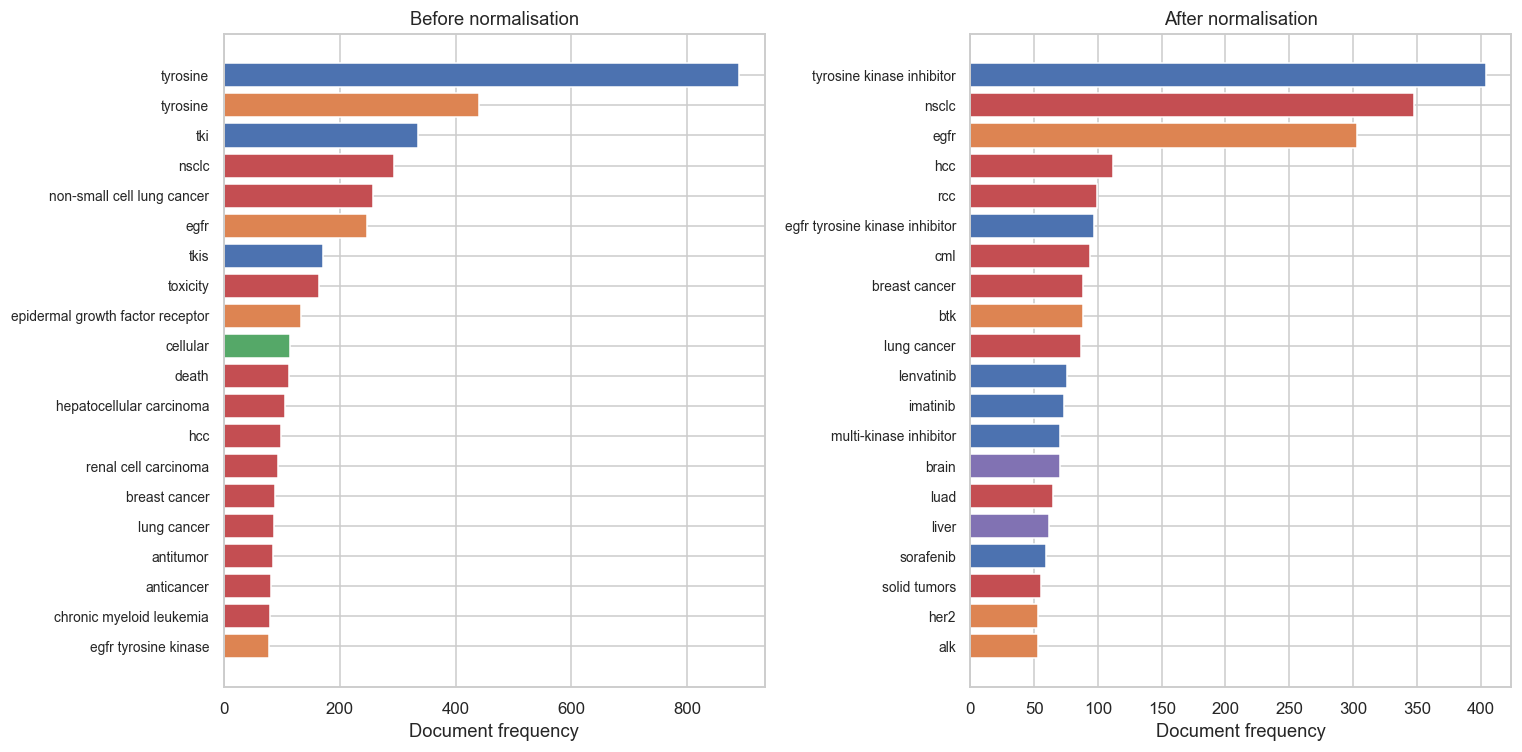

In [6]:
# Side-by-side bar chart of top entities
fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharex=False)

for ax, df_top, title in [
    (axes[0], before_top, "Before normalisation"),
    (axes[1], after_top, "After normalisation"),
]:
    df_top = df_top.iloc[::-1]  # reverse for horizontal bar
    type_colors = {"CHEMICAL": "#4c72b0", "GENE": "#dd8452",
                   "DISEASE": "#c44e52", "CELL": "#55a868",
                   "ANATOMY": "#8172b3"}
    colors = [type_colors.get(t, "#888") for t in df_top["type"]]
    ax.barh(range(len(df_top)), df_top["doc_freq"], color=colors)
    ax.set_yticks(range(len(df_top)))
    ax.set_yticklabels(df_top["norm"], fontsize=9)
    ax.set_xlabel("Document frequency")
    ax.set_title(title)

plt.tight_layout()
plt.savefig(FIG_DIR / "07_top_entities_before_after.png", bbox_inches="tight")
plt.show()


## 4. Build the normalised graph

Same parameters as notebook 02 for a fair comparison: `min_count=8`,
`min_edge_weight=4`, types restricted to CHEMICAL / GENE / DISEASE /
CELL.

In [7]:
MIN_COUNT = 8
KEEP_TYPES = ["CHEMICAL", "GENE", "DISEASE", "CELL"]
MIN_EDGE_WEIGHT = 4

ents_f = filter_entities(ents_norm, min_count=MIN_COUNT, keep_types=KEEP_TYPES)
edges_norm = cooccurrence_edges(ents_f)
G_norm = build_graph(edges_norm, min_weight=MIN_EDGE_WEIGHT)
print(f"Normalised graph: {G_norm.number_of_nodes()} nodes, "
      f"{G_norm.number_of_edges()} edges")
print(f"Density: {nx.density(G_norm):.4f}")
print(f"Components: {nx.number_connected_components(G_norm)}")

# Original graph for comparison
ents_f_raw = filter_entities(ents_raw, min_count=MIN_COUNT, keep_types=KEEP_TYPES)
edges_raw = cooccurrence_edges(ents_f_raw)
G_raw = build_graph(edges_raw, min_weight=MIN_EDGE_WEIGHT)
print()
print(f"Raw graph (for comparison): {G_raw.number_of_nodes()} nodes, "
      f"{G_raw.number_of_edges()} edges")


Normalised graph: 242 nodes, 804 edges
Density: 0.0276
Components: 7

Raw graph (for comparison): 347 nodes, 1934 edges


## 5. Centrality — does the artificial hub disappear?

In the raw graph, "tyrosine" had weighted degree 4,234 — over 2×
the next node. After normalisation it should be gone entirely, and
the top hubs should be actual diseases and drugs.

In [8]:
cent_norm = centrality_table(G_norm)
cent_raw = centrality_table(G_raw)

print("BEFORE — top 15 by weighted degree:")
print(cent_raw.head(15)[["node", "type", "weighted_degree", "betweenness"]].to_string(index=False))
print()
print("AFTER — top 15 by weighted degree:")
print(cent_norm.head(15)[["node", "type", "weighted_degree", "betweenness"]].to_string(index=False))


BEFORE — top 15 by weighted degree:
                            node     type  weighted_degree  betweenness
                        tyrosine CHEMICAL             4234     0.702134
                             tki CHEMICAL             1835     0.067281
                           nsclc  DISEASE             1629     0.024479
                            egfr     GENE             1521     0.030643
      non-small cell lung cancer  DISEASE             1017     0.022708
                        toxicity  DISEASE              828     0.023923
                            tkis CHEMICAL              784     0.019841
epidermal growth factor receptor     GENE              770     0.003384
        hepatocellular carcinoma  DISEASE              530     0.004026
                             hcc  DISEASE              518     0.003511
                           death  DISEASE              425     0.005867
                     lung cancer  DISEASE              414     0.002303
            renal cell carci

In [9]:
# Compare betweenness concentration — how much does the top node hog?
def top_share(cent_df):
    """Share of total betweenness held by the top node."""
    total = cent_df["betweenness"].sum()
    if total == 0:
        return 0.0
    return cent_df["betweenness"].max() / total

print(f"Top-node betweenness share — raw:        {top_share(cent_raw):.1%}")
print(f"Top-node betweenness share — normalised: {top_share(cent_norm):.1%}")
print()
print("(Lower is better: a healthy network distributes information flow.)")


Top-node betweenness share — raw:        64.8%
Top-node betweenness share — normalised: 30.6%

(Lower is better: a healthy network distributes information flow.)


## 6. Communities — sharper after normalisation?

In [10]:
comm_raw = communities(G_raw)
comm_norm = communities(G_norm)

n_raw = len(set(comm_raw.values()))
n_norm = len(set(comm_norm.values()))

# Sizes (largest first)
sizes_raw = pd.Series(list(comm_raw.values())).value_counts().sort_values(ascending=False)
sizes_norm = pd.Series(list(comm_norm.values())).value_counts().sort_values(ascending=False)

print(f"Raw graph:        {n_raw} communities")
print(f"  sizes: {sizes_raw.tolist()}")
print()
print(f"Normalised graph: {n_norm} communities")
print(f"  sizes: {sizes_norm.tolist()}")


Raw graph:        13 communities
  sizes: [129, 96, 78, 23, 5, 4, 3, 3, 2, 1, 1, 1, 1]

Normalised graph: 19 communities
  sizes: [87, 50, 41, 24, 11, 5, 4, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1]


In [11]:
# Top members of each community after normalisation
wdeg = dict(G_norm.degree(weight="weight"))
comm_df = pd.DataFrame([
    {"node": n, "type": G_norm.nodes[n]["type"], "community": c,
     "weighted_degree": wdeg[n]}
    for n, c in comm_norm.items()
])

print("Top 6 nodes per community (normalised graph):")
for cid in sorted(comm_df["community"].unique()):
    sub = (comm_df[comm_df["community"] == cid]
           .sort_values("weighted_degree", ascending=False)
           .head(6))
    nodes_str = ", ".join(f"{r['node']} ({r['type'][0]})"
                          for _, r in sub.iterrows())
    size = (comm_df["community"] == cid).sum()
    print(f"  C{cid} (n={size:>3}): {nodes_str}")


Top 6 nodes per community (normalised graph):
  C0 (n= 87): tyrosine kinase inhibitor (C), nsclc (D), egfr (G), lung cancer (D), egfr tyrosine kinase inhibitor (C), luad (D)
  C1 (n= 50): btk (G), her2 (G), breast cancer (D), hypertension (D), diarrhea (D), cll (D)
  C2 (n= 41): hcc (D), rcc (D), lenvatinib (C), multi-kinase inhibitor (C), cabozantinib (C), sorafenib (C)
  C3 (n= 24): cml (D), imatinib (C), dasatinib (C), myeloid leukemia (D), nilotinib (C), tfr (G)
  C4 (n= 11): cd8 (G), t cells (C), pd-1 (G), pd-l1 (G), tumor immune (D), t-cell (C)
  C5 (n=  5): tcga (D), cdkn2a (G), cyclin-dependent kinase inhibitor 2a (G), p53 (G), geo (G)
  C6 (n=  4): mek (C), erk (G), mapk (G), trametinib (C)
  C7 (n=  2): gbm (D), glioblastoma (D)
  C8 (n=  2): jak (G), ruxolitinib (C)
  C9 (n=  2): aml (D), flt3 (G)
  C10 (n=  2): mtor (G), everolimus (C)
  C11 (n=  2): braf (G), melanoma (D)
  C12 (n=  2): renal (D), creatinine (C)
  C13 (n=  2): bcl-2 (G), bax (G)
  C14 (n=  2): gemcitabine 

## 7. Static visualisation of the normalised network

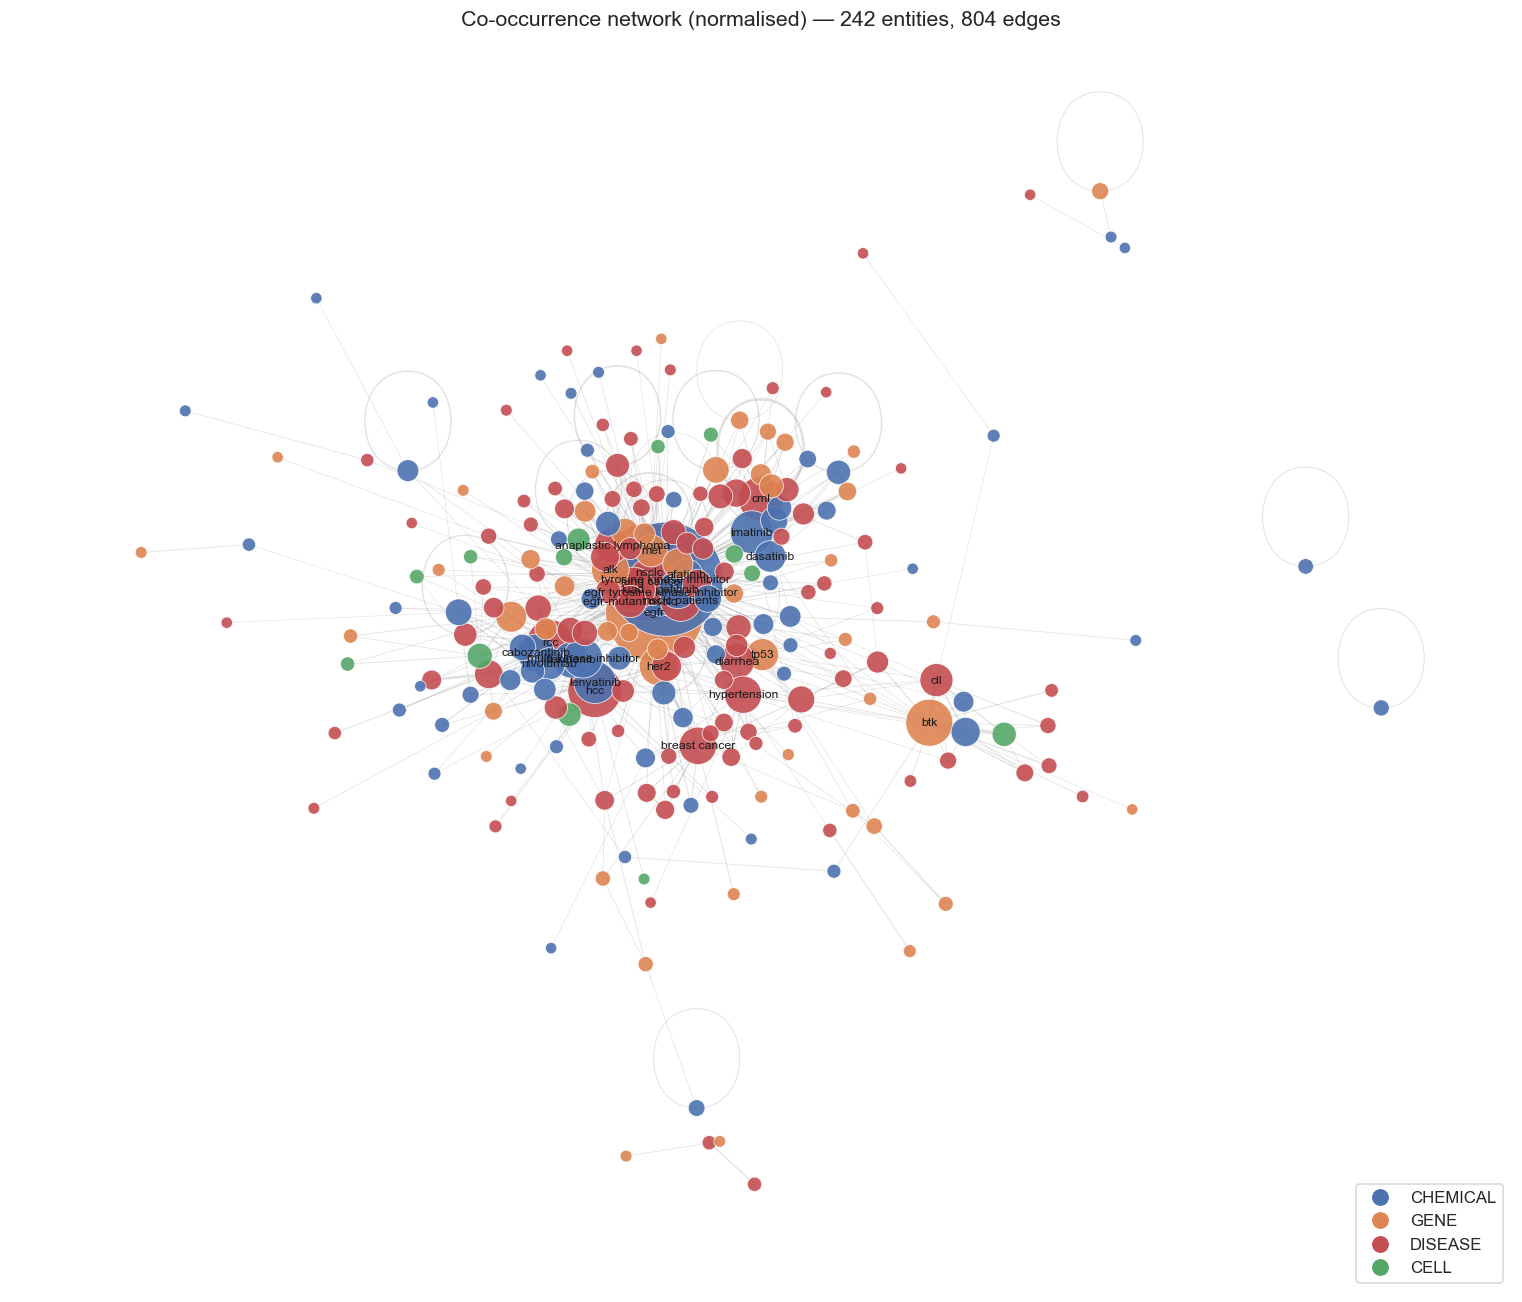

In [12]:
TYPE_COLORS = {
    "CHEMICAL": "#4c72b0",
    "GENE":     "#dd8452",
    "DISEASE":  "#c44e52",
    "CELL":     "#55a868",
}

pos = nx.spring_layout(G_norm, seed=42, k=0.5, iterations=80)
node_colors = [TYPE_COLORS.get(G_norm.nodes[n]["type"], "#888") for n in G_norm.nodes()]
node_sizes = [40 + wdeg[n] * 4 for n in G_norm.nodes()]
edge_widths = [min(0.2 + G_norm[u][v]["weight"] * 0.05, 3.0)
               for u, v in G_norm.edges()]

fig, ax = plt.subplots(figsize=(14, 12))
nx.draw_networkx_edges(G_norm, pos, ax=ax, alpha=0.25, width=edge_widths,
                       edge_color="#888")
nx.draw_networkx_nodes(G_norm, pos, ax=ax, node_size=node_sizes,
                       node_color=node_colors, alpha=0.9, linewidths=0.5,
                       edgecolors="white")

top_label_n = 30
top_nodes = set(cent_norm.head(top_label_n)["node"])
labels = {n: n for n in G_norm.nodes() if n in top_nodes}
nx.draw_networkx_labels(G_norm, pos, labels=labels, ax=ax, font_size=8)

from matplotlib.lines import Line2D
legend = [Line2D([0], [0], marker='o', linestyle='', color=c,
                  markersize=10, label=t)
          for t, c in TYPE_COLORS.items()]
ax.legend(handles=legend, loc="lower right", frameon=True)
ax.set_title(f"Co-occurrence network (normalised) — "
             f"{G_norm.number_of_nodes()} entities, "
             f"{G_norm.number_of_edges()} edges", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.savefig(FIG_DIR / "08_network_normalised.png", bbox_inches="tight", dpi=150)
plt.show()


## 8. Drug ↔ Gene and Drug ↔ Disease subgraphs (normalised)

In [13]:
def filter_subgraph_by_types(G, type_pairs):
    H = nx.Graph()
    for u, v, d in G.edges(data=True):
        tu = G.nodes[u]["type"]
        tv = G.nodes[v]["type"]
        if frozenset({tu, tv}) in type_pairs:
            for n in (u, v):
                if n not in H:
                    H.add_node(n, **G.nodes[n])
            H.add_edge(u, v, **d)
    return H


def top_edges(H, n=20):
    return (pd.DataFrame([{"a": u, "b": v, **d} for u, v, d in H.edges(data=True)])
            .sort_values("weight", ascending=False).head(n))


drug_target = filter_subgraph_by_types(G_norm, {frozenset({"CHEMICAL", "GENE"})})
drug_disease = filter_subgraph_by_types(G_norm, {frozenset({"CHEMICAL", "DISEASE"})})

print(f"Drug ↔ Gene:    {drug_target.number_of_nodes()} nodes, "
      f"{drug_target.number_of_edges()} edges")
print(f"Drug ↔ Disease: {drug_disease.number_of_nodes()} nodes, "
      f"{drug_disease.number_of_edges()} edges")
print()
print("Top drug ↔ gene edges (normalised):")
print(top_edges(drug_target).to_string(index=False))
print()
print("Top drug ↔ disease edges (normalised):")
print(top_edges(drug_disease).to_string(index=False))


Drug ↔ Gene:    71 nodes, 85 edges
Drug ↔ Disease: 134 nodes, 207 edges

Top drug ↔ gene edges (normalised):
                        a                                                       b  weight       pmi
                     egfr                               tyrosine kinase inhibitor     137  0.664252
                     egfr                                               gefitinib      32  2.095149
                      btk                                               ibrutinib      30  3.870670
                     egfr                                                afatinib      25  2.167848
                     egfr                          egfr tyrosine kinase inhibitor      21  2.224432
                     egfr                                               erlotinib      20  1.902503
tyrosine kinase inhibitor                                                   t790m      16  1.285832
tyrosine kinase inhibitor                                                     met      15  

## 9. Interactive HTML (normalised)

In [14]:
from pyvis.network import Network

net = Network(height="700px", width="100%", bgcolor="#ffffff",
              font_color="#222", notebook=False, cdn_resources="in_line")
net.barnes_hut(spring_length=120, spring_strength=0.02, damping=0.4)

for n, d in G_norm.nodes(data=True):
    color = TYPE_COLORS.get(d["type"], "#888")
    size = 10 + wdeg[n] * 0.8
    title = f"{n}\n{d['type']} | weighted_degree={wdeg[n]}"
    net.add_node(n, label=n, color=color, size=size, title=title)

for u, v, d in G_norm.edges(data=True):
    net.add_edge(u, v, value=d["weight"],
                 title=f"weight={d['weight']}, pmi={d['pmi']:.2f}")

out_html = FIG_DIR.parent / "network_normalised.html"
net.write_html(str(out_html), notebook=False)
print(f"Interactive normalised network → {out_html}")


Interactive normalised network → ../reports/network_normalised.html
